# Forward corruption: cosine vs linear

/opt/anaconda3/envs/ocr_environment/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


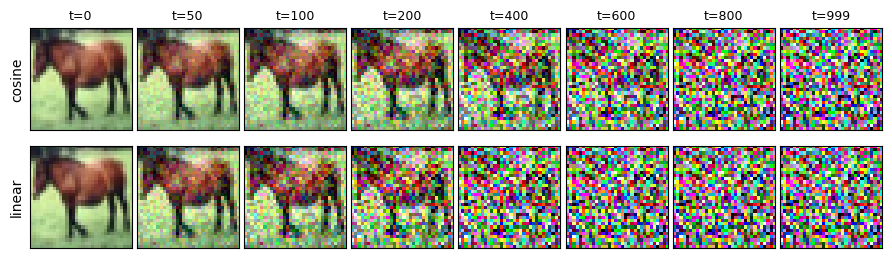

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch, math
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10
from torchvision import transforms
from diffusion import make_schedule

T = 1000
ts = [0, 50, 100, 200, 400, 600, 800, 999]

abar = {}
for name in ["cosine", "linear"]:
    betas = make_schedule(name, T)
    abar[name] = torch.cumprod(1.0 - betas, dim=0)

ds = CIFAR10(root="./data", train=True, download=True,
             transform=transforms.Compose([transforms.ToTensor(),
                                           transforms.Normalize((0.5,)*3,(0.5,)*3)]))
x0, _ = ds[7]
torch.manual_seed(0)
eps = torch.randn_like(x0)

fig, axes = plt.subplots(2, len(ts), figsize=(11, 3),
                         gridspec_kw={"hspace": 0.05, "wspace": 0.05})

for row, name in enumerate(["cosine", "linear"]):
    a = abar[name]
    for col, t in enumerate(ts):
        x_t = torch.sqrt(a[t]) * x0 + torch.sqrt(1 - a[t]) * eps
        img = ((x_t.clamp(-1, 1) + 1) / 2).permute(1, 2, 0).numpy()
        sub = axes[row, col]
        sub.imshow(img); sub.set_xticks([]); sub.set_yticks([])
        if row == 0: sub.set_title(f"t={t}", fontsize=9)
        if col == 0: sub.set_ylabel(name, fontsize=10)

plt.show()

# Schedule comparison: cosine vs linear

Compute FID against CIFAR-10 train for the two sample directories generated at step 300000 and 600000.

In [2]:
import torch
from cleanfid import fid
import os, re, glob
import matplotlib.pyplot as plt

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

FID_ROOT = "fid_samples"
SCHEDULES = ["cosine", "linear"]

In [3]:
def keep(step):
    if step == 25000:
        return True
    return step % 50000 == 0

In [4]:
all_results = {}

runs = [
    ("cos_eps_medium_no_ema",   r"exp1_schedule_cosine_step(\d+)$", "exp1_schedule_cosine_step*"),
    ("lin_eps_medium_no_ema", r"exp1_schedule_linear_step(\d+)$","exp1_schedule_linear_step*"),
    ("cos_eps_medium_with_ema",  r"exp2_ema_on_step(\d+)$",  "exp2_ema_on_step*"),
    ("lin_eps_medium_with_ema",   r"exp2_ema_on_linear_step(\d+)$", "exp2_ema_on_linear_step*"),
    ("cos_x0_medium_with_ema", r"exp3_predict_x0_step(\d+)$",  "exp3_predict_x0_step*"),
    ("cos_eps_small_with_ema",   r"exp4_size_small_step(\d+)$",   "exp4_size_small_step*"),
    ("cos_eps_large_with_ema",  r"exp4_size_large_step(\d+)$",  "exp4_size_large_step*"),
]

for name, pat_str, glob_str in runs:
    pat = re.compile(pat_str)
    steps = []
    fids  = []
    for d in sorted(glob.glob(os.path.join(FID_ROOT, glob_str))):
        m = pat.search(os.path.basename(d))
        if not m: continue
        step = int(m.group(1))
        if not keep(step):
            continue
        score = fid.compute_fid(d, dataset_name="cifar10", dataset_res=32,
                                dataset_split="train", device=DEVICE, num_workers=0)
        print(name, "step", step, "FID =", round(float(score),3))
        steps.append(step)
        fids.append(float(score))
    all_results[name] = {"steps": steps, "fid": fids}

cos_eps_medium_no_ema   = all_results["cos_eps_medium_no_ema"]
lin_eps_medium_no_ema   = all_results["lin_eps_medium_no_ema"]
cos_eps_medium_with_ema = all_results["cos_eps_medium_with_ema"]
lin_eps_medium_with_ema = all_results["lin_eps_medium_with_ema"]
cos_x0_medium_with_ema  = all_results["cos_x0_medium_with_ema"]
cos_eps_small_with_ema  = all_results["cos_eps_small_with_ema"]
cos_eps_large_with_ema  = all_results["cos_eps_large_with_ema"]
all_results

compute FID of a folder with cifar10 statistics
Found 10000 images in the folder fid_samples/exp1_schedule_cosine_step100000


FID exp1_schedule_cosine_step100000 : 100%|██████████| 313/313 [00:35<00:00,  8.72it/s]


cos_eps_medium_no_ema step 100000 FID = 28.802
compute FID of a folder with cifar10 statistics
Found 10000 images in the folder fid_samples/exp1_schedule_cosine_step150000


FID exp1_schedule_cosine_step150000 : 100%|██████████| 313/313 [00:36<00:00,  8.63it/s]


cos_eps_medium_no_ema step 150000 FID = 31.604
compute FID of a folder with cifar10 statistics
Found 10000 images in the folder fid_samples/exp1_schedule_cosine_step200000


...

FID exp4_size_large_step550000 : 100%|██████████| 313/313 [00:40<00:00,  7.63it/s]


cos_eps_large_with_ema step 550000 FID = 23.185
compute FID of a folder with cifar10 statistics
Found 10000 images in the folder fid_samples/exp4_size_large_step600000


FID exp4_size_large_step600000 : 100%|██████████| 313/313 [00:41<00:00,  7.59it/s]


cos_eps_large_with_ema step 600000 FID = 25.351


{'cos_eps_medium_no_ema': {'steps': [100000,
   150000,
   200000,
   25000,
   250000,
   300000,
   350000,
   400000,
   450000,
   50000,
   500000,
   550000,
   600000],
  'fid': [28.801849381745342,
   31.603627170723655,
   27.472685316282366,
   56.62142140252166,
   24.814032374078806,
   29.67586246956887,
   27.051982590589887,
   23.276025246799065,
   23.542656134562094,
   27.171052084536655,
   29.362125380460725,
   22.474321784950234,
   23.82269392263572]},
 'lin_eps_medium_no_ema': {'steps': [100000,
   150000,
   200000,
   25000,
   250000,
   300000,
   350000,
   400000,
   450000,
   50000,
   500000,
   550000,
   600000],
  'fid': [31.630382398072072,
   26.756443716726153,
   23.78101254406471,
   43.0414563874009,
   20.378647381034853,
   25.770774359467737,
   23.651522832664682,
   31.978204338345563,
   29.678603237284165,
   30.520295218734134,
   23.4942222342454,
   22.150822366949114,
   24.65324873351767]},
 'cos_eps_medium_with_ema': {'steps': [10

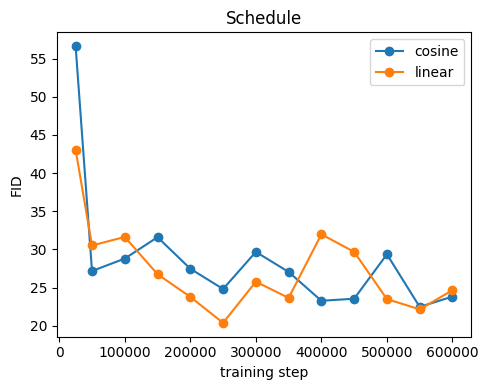

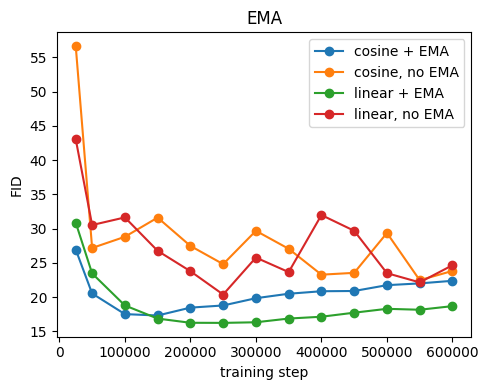

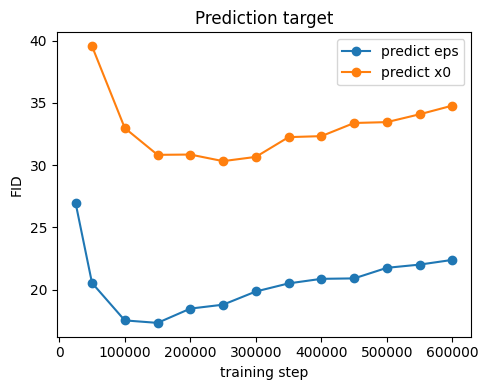

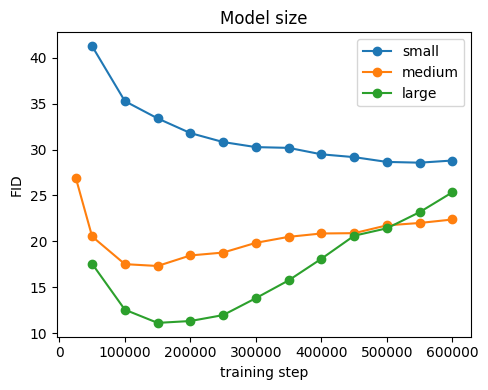

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def sort_by_step(r):
    order = np.argsort(r["steps"])
    return np.array(r["steps"])[order], np.array(r["fid"])[order]

# Exp 1: cosine vs linear schedule
plt.figure(figsize=(5, 4))
s, f = sort_by_step(cos_eps_medium_no_ema); plt.plot(s, f, "-o", label="cosine")
s, f = sort_by_step(lin_eps_medium_no_ema); plt.plot(s, f, "-o", label="linear")
plt.title("Schedule")
plt.xlabel("training step"); plt.ylabel("FID")
plt.legend()
plt.tight_layout()
plt.show()

# Exp 2: EMA vs no EMA
plt.figure(figsize=(5, 4))
s, f = sort_by_step(cos_eps_medium_with_ema); plt.plot(s, f, "-o", label="cosine + EMA")
s, f = sort_by_step(cos_eps_medium_no_ema);   plt.plot(s, f, "-o", label="cosine, no EMA")
s, f = sort_by_step(lin_eps_medium_with_ema); plt.plot(s, f, "-o", label="linear + EMA")
s, f = sort_by_step(lin_eps_medium_no_ema);   plt.plot(s, f, "-o", label="linear, no EMA")
plt.title("EMA")
plt.xlabel("training step"); plt.ylabel("FID")
plt.legend()
plt.tight_layout()
plt.show()

# Exp 3: prediction target
plt.figure(figsize=(5, 4))
s, f = sort_by_step(cos_eps_medium_with_ema); plt.plot(s, f, "-o", label="predict eps")
s, f = sort_by_step(cos_x0_medium_with_ema);  plt.plot(s, f, "-o", label="predict x0")
plt.title("Prediction target")
plt.xlabel("training step"); plt.ylabel("FID")
plt.legend()
plt.tight_layout()
plt.show()

# Exp 4: model size
plt.figure(figsize=(5, 4))
s, f = sort_by_step(cos_eps_small_with_ema);  plt.plot(s, f, "-o", label="small")
s, f = sort_by_step(cos_eps_medium_with_ema); plt.plot(s, f, "-o", label="medium")
s, f = sort_by_step(cos_eps_large_with_ema);  plt.plot(s, f, "-o", label="large")
plt.title("Model size")
plt.xlabel("training step"); plt.ylabel("FID")
plt.legend()
plt.tight_layout()
plt.show()